In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('../data/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create monthly time series — this is our forecasting base
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='MS')
)['Sales'].sum().reset_index()
monthly_sales.columns = ['Date', 'Sales']

print("Forecasting data ready!")
print(f"Total months: {len(monthly_sales)}")
print(monthly_sales.tail())

Forecasting data ready!
Total months: 48
         Date        Sales
43 2017-08-01   63120.8880
44 2017-09-01   87866.6520
45 2017-10-01   77776.9232
46 2017-11-01  118447.8250
47 2017-12-01   83829.3188


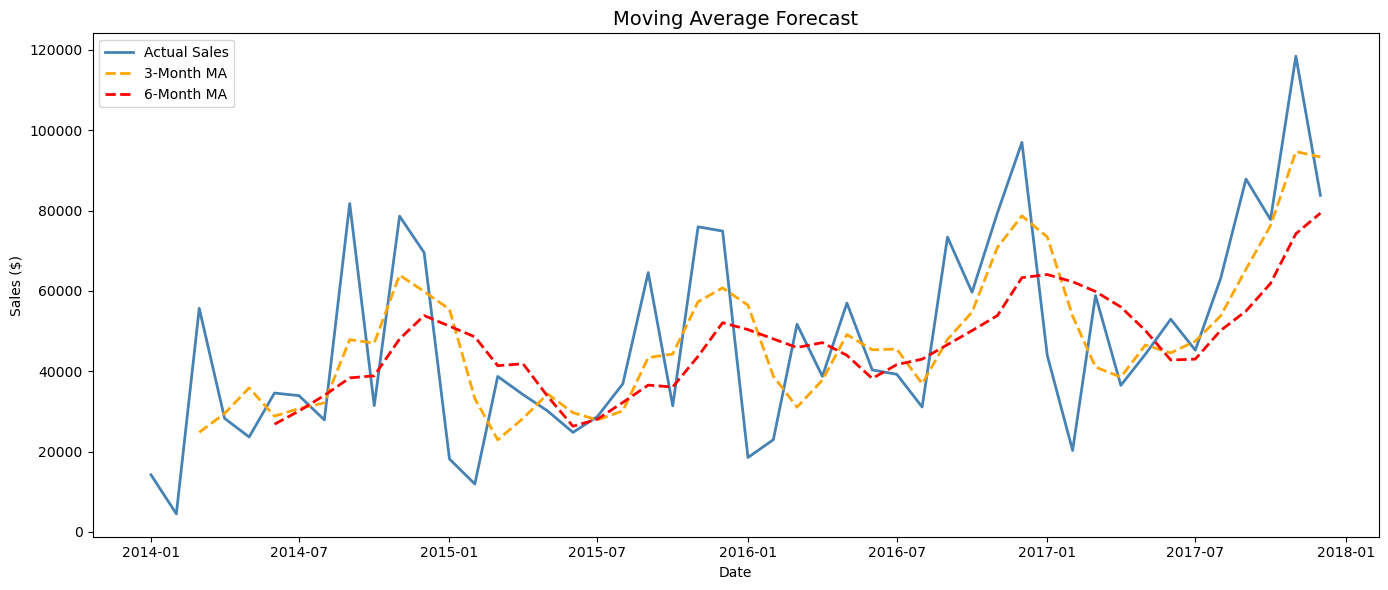

Chart saved!


In [2]:
# MOVING AVERAGE — simplest forecasting method
# Uses average of last N months to predict next month
# Used in basic demand planning when no complex patterns exist

train = monthly_sales[:-6]  # use all except last 6 months
test = monthly_sales[-6:]   # last 6 months = test period

# Calculate 3-month and 6-month moving averages
monthly_sales['MA_3'] = monthly_sales['Sales'].rolling(window=3).mean()
monthly_sales['MA_6'] = monthly_sales['Sales'].rolling(window=6).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], 
         label='Actual Sales', color='steelblue', linewidth=2)
plt.plot(monthly_sales['Date'], monthly_sales['MA_3'], 
         label='3-Month MA', color='orange', linewidth=2, linestyle='--')
plt.plot(monthly_sales['Date'], monthly_sales['MA_6'], 
         label='6-Month MA', color='red', linewidth=2, linestyle='--')

plt.title('Moving Average Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/moving_average.png', dpi=150)
plt.show()
print("Chart saved!")

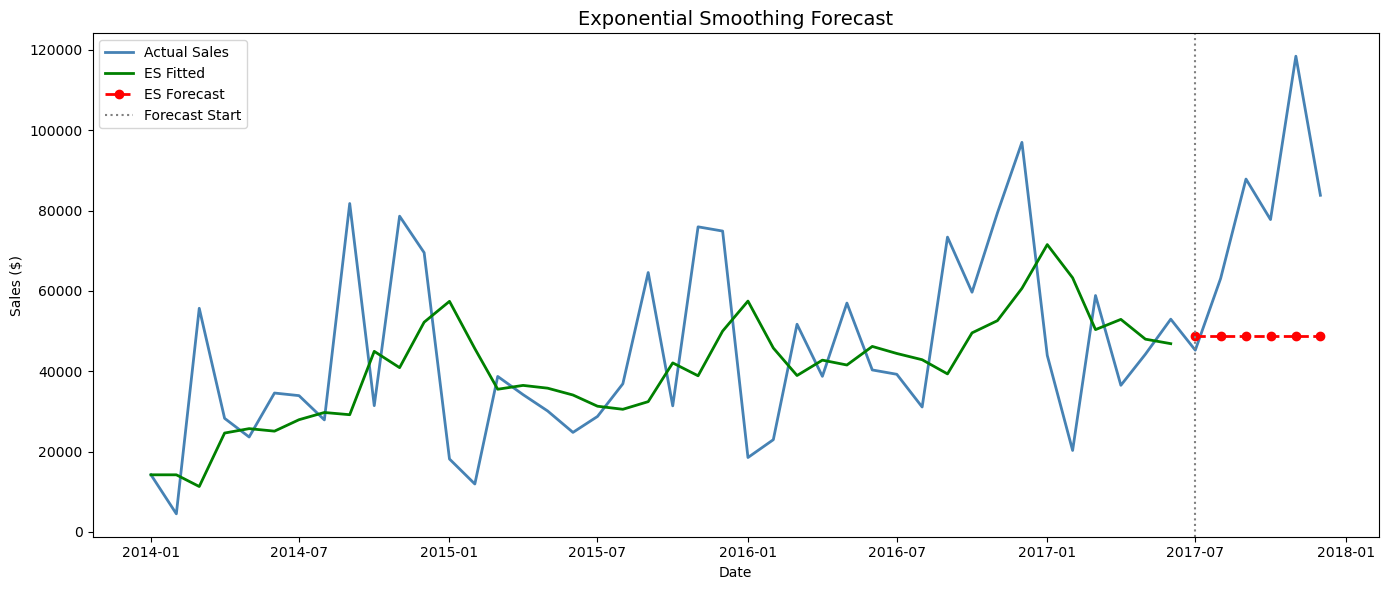

Chart saved!


In [3]:
# EXPONENTIAL SMOOTHING — smarter than MA
# Gives more weight to recent data, less to older data
# Used in S&OP tools like o9 for short-term demand forecasting

train_data = monthly_sales['Sales'][:-6]
test_data = monthly_sales['Sales'][-6:]

# Fit the model
model = SimpleExpSmoothing(train_data)
fit = model.fit(smoothing_level=0.3, optimized=False)

# Forecast next 6 months
forecast = fit.forecast(6)
forecast_dates = monthly_sales['Date'][-6:]

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], 
         label='Actual Sales', color='steelblue', linewidth=2)
plt.plot(monthly_sales['Date'][:-6], fit.fittedvalues, 
         label='ES Fitted', color='green', linewidth=2)
plt.plot(forecast_dates, forecast.values, 
         label='ES Forecast', color='red', linewidth=2, 
         linestyle='--', marker='o')

plt.axvline(x=monthly_sales['Date'].iloc[-6], 
            color='gray', linestyle=':', label='Forecast Start')
plt.title('Exponential Smoothing Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/exp_smoothing.png', dpi=150)
plt.show()
print("Chart saved!")

In [4]:
# FORECAST ERROR METRICS — how good is our forecast?
# MAE = Mean Absolute Error (in dollars)
# MAPE = Mean Absolute Percentage Error (in %)
# Lower is better!

actual = test_data.values
predicted_ma = monthly_sales['MA_3'][-6:].values
predicted_es = forecast.values

def calculate_metrics(actual, predicted, model_name):
    mae = np.mean(np.abs(actual - predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{model_name}:")
    print(f"  MAE  = ${mae:,.0f}")
    print(f"  MAPE = {mape:.1f}%")
    return mae, mape

print("=== FORECAST ACCURACY ===\n")
mae_ma, mape_ma = calculate_metrics(actual, predicted_ma, "Moving Average (3-month)")
print()
mae_es, mape_es = calculate_metrics(actual, predicted_es, "Exponential Smoothing")
print()

if mape_es < mape_ma:
    print("✅ Winner: Exponential Smoothing performs better!")
else:
    print("✅ Winner: Moving Average performs better!")

=== FORECAST ACCURACY ===

Moving Average (3-month):
  MAE  = $11,469
  MAPE = 13.1%

Exponential Smoothing:
  MAE  = $31,820
  MAPE = 35.5%

✅ Winner: Moving Average performs better!


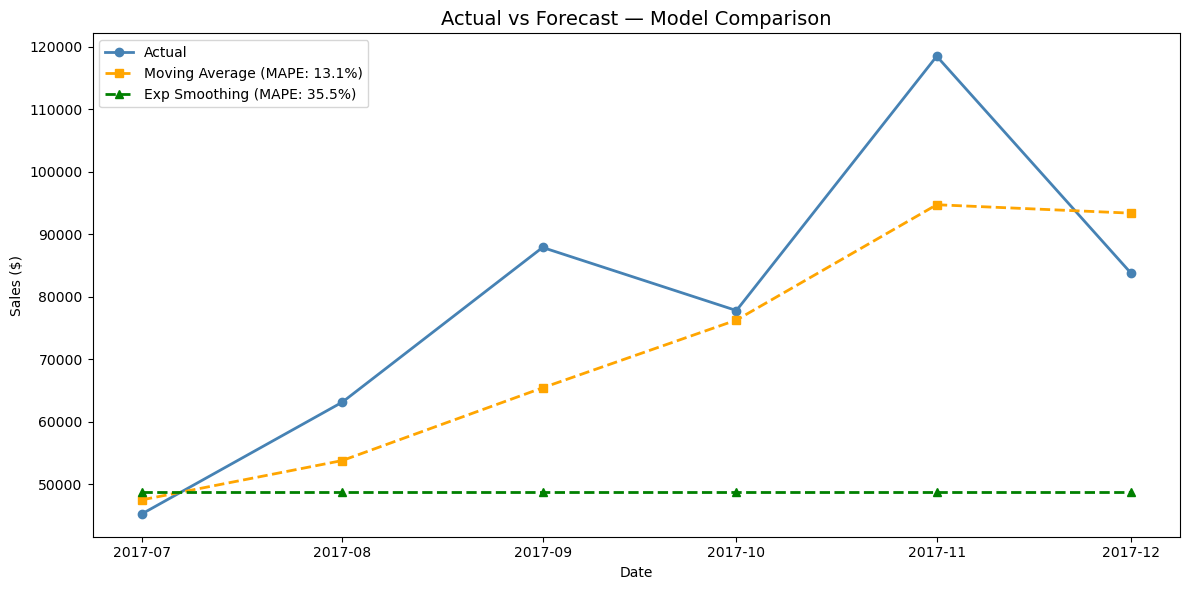

Chart saved!


In [5]:
# Visual comparison — Actual vs Both Models
plt.figure(figsize=(12, 6))
plt.plot(forecast_dates, actual, 
         label='Actual', color='steelblue', 
         linewidth=2, marker='o')
plt.plot(forecast_dates, predicted_ma, 
         label=f'Moving Average (MAPE: {mape_ma:.1f}%)', 
         color='orange', linewidth=2, marker='s', linestyle='--')
plt.plot(forecast_dates, predicted_es, 
         label=f'Exp Smoothing (MAPE: {mape_es:.1f}%)', 
         color='green', linewidth=2, marker='^', linestyle='--')

plt.title('Actual vs Forecast — Model Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

In [6]:
print("=== 03_FORECASTING_MODELS SUMMARY ===")
print(f"Training data: {len(train_data)} months")
print(f"Test period: 6 months")
print(f"\nModel Performance:")
print(f"  Moving Average  → MAPE: {mape_ma:.1f}%")
print(f"  Exp Smoothing   → MAPE: {mape_es:.1f}%")
winner = "Exponential Smoothing" if mape_es < mape_ma else "Moving Average"
print(f"\n🏆 Best Model: {winner}")
print(f"\nCharts saved:")
print("  - moving_average.png")
print("  - exp_smoothing.png")
print("  - model_comparison.png")

=== 03_FORECASTING_MODELS SUMMARY ===
Training data: 42 months
Test period: 6 months

Model Performance:
  Moving Average  → MAPE: 13.1%
  Exp Smoothing   → MAPE: 35.5%

🏆 Best Model: Moving Average

Charts saved:
  - moving_average.png
  - exp_smoothing.png
  - model_comparison.png
